# ML Practical Code

## Linear Regression

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 3 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Student_ID               50 non-null     str    
 1   MBA_Percentage           50 non-null     float64
 2   Salary_Package (in LPA)  50 non-null     float64
dtypes: float64(2), str(1)
memory usage: 1.5 KB


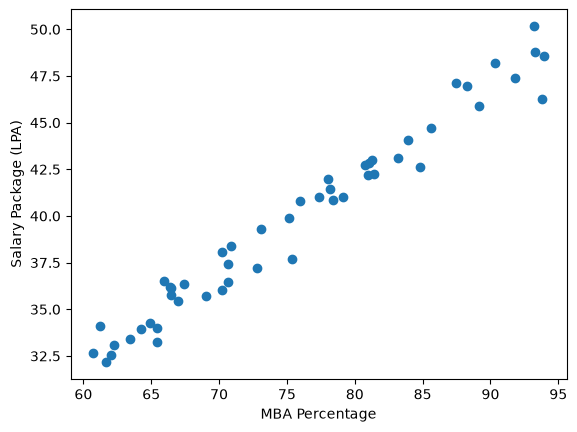

Slope (m): 0.4921495909258523
Intercept (c): 2.5936515734581604
R2 Score: 0.9502122789530665
RMSE: 0.8922978631540237


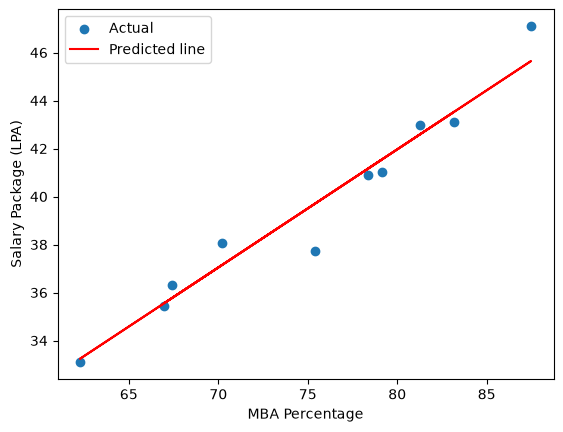

Predicted salary for 85%: 44.426366802155606


In [1]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Step 2: Load the dataset
df = pd.read_csv("simple linear regression/mba_salary_data_ (1).csv")
df.head()

# Step 3: Explore the data
df.shape          # rows and columns
df.describe()     # mean, min, max, quartiles
df.info()         # data types and null counts

# Step 4: Features (X) and target (y)
# Double brackets keep X 2-D, which sklearn requires
X = df[["MBA_Percentage"]]
y = df["Salary_Package (in LPA)"]

# Step 5: Scatter plot to check the relationship is linear
plt.scatter(X, y)
plt.xlabel("MBA Percentage")
plt.ylabel("Salary Package (LPA)")
plt.show()

# Step 6: Split into training and testing data (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Step 7: Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 8: The fitted line  y = mx + c
print("Slope (m):", model.coef_[0])
print("Intercept (c):", model.intercept_)

# Step 9: Predict on the test set
y_pred = model.predict(X_test)

# Step 10: Evaluate
# R2 = how much of the salary variation the model explains (1.0 is perfect)
# RMSE = average error, in LPA
print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

# Step 11: Plot the regression line over the actual points
plt.scatter(X_test, y_test, label="Actual")
plt.plot(X_test, y_pred, color="red", label="Predicted line")
plt.xlabel("MBA Percentage")
plt.ylabel("Salary Package (LPA)")
plt.legend()
plt.show()

# Step 12: Predict the salary of a new student
new_student = pd.DataFrame({"MBA_Percentage": [85]})
print("Predicted salary for 85%:", model.predict(new_student)[0])


## Logistic Regression

In [2]:
# Step 1: Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Step 2: Load the dataset
df = pd.read_csv("logical regression/german_credit_risk (1).csv")
df.head()
df.shape

# Step 3: Remove the unnamed index column
df = df.drop("Unnamed: 0", axis=1)
df.isnull().sum()     # Saving accounts and Checking account have missing values

# Step 4: Fill missing categorical values with the mode (most common value)
cat_cols = ["Sex", "Housing", "Saving accounts",
            "Checking account", "Purpose"]

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Step 5: Convert categorical columns into dummy (0/1) variables
# drop_first=True avoids the dummy variable trap
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Step 6: Convert the target into numbers
df["Risk"] = df["Risk"].map({"bad": 0, "good": 1})

# Step 7: Features (X) and target (y)
X = df.drop("Risk", axis=1)
y = df["Risk"]

# Step 8: Split the data
# stratify=y keeps the same good/bad ratio in train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

# Step 9: Feature scaling
# fit_transform on train only, transform on test (never fit on test data)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 10: Train the model
# max_iter=1000 stops the convergence warning
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

# Step 11: Predict on the test set
y_pred = model.predict(X_test_scaled)

# Step 12: Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))            # rows = actual, columns = predicted
print(classification_report(y_test, y_pred))       # precision, recall, f1-score

# Step 13: Create a new customer
new_customer = pd.DataFrame({
    "Age": [30],
    "Sex": ["male"],
    "Job": [2],
    "Housing": ["own"],
    "Saving accounts": ["little"],
    "Checking account": ["moderate"],
    "Credit amount": [4000],
    "Duration": [24],
    "Purpose": ["car"]
})

# Step 14: Apply the SAME preprocessing used on the training data
# reindex forces the new row to have exactly the training columns
new_customer = pd.get_dummies(new_customer, columns=cat_cols, drop_first=True)
new_customer = new_customer.reindex(columns=X.columns, fill_value=0)

# Step 15: Scale with the same scaler, then predict
new_customer_scaled = scaler.transform(new_customer)
prediction = model.predict(new_customer_scaled)

if prediction[0] == 1:
    print("Prediction: GOOD CREDIT RISK")
else:
    print("Prediction: BAD CREDIT RISK")

# Step 16: Probability of each class (column 1 = good risk)
probability = model.predict_proba(new_customer_scaled)
print("Probability of Good Risk:", probability[0][1])


Accuracy: 0.7
[[ 15  45]
 [ 15 125]]
              precision    recall  f1-score   support

           0       0.50      0.25      0.33        60
           1       0.74      0.89      0.81       140

    accuracy                           0.70       200
   macro avg       0.62      0.57      0.57       200
weighted avg       0.66      0.70      0.66       200

Prediction: GOOD CREDIT RISK
Probability of Good Risk: 0.5452266082339331


## Decision Tree

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 9.1 KB
Accuracy: 1.0
confusion matrix: [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


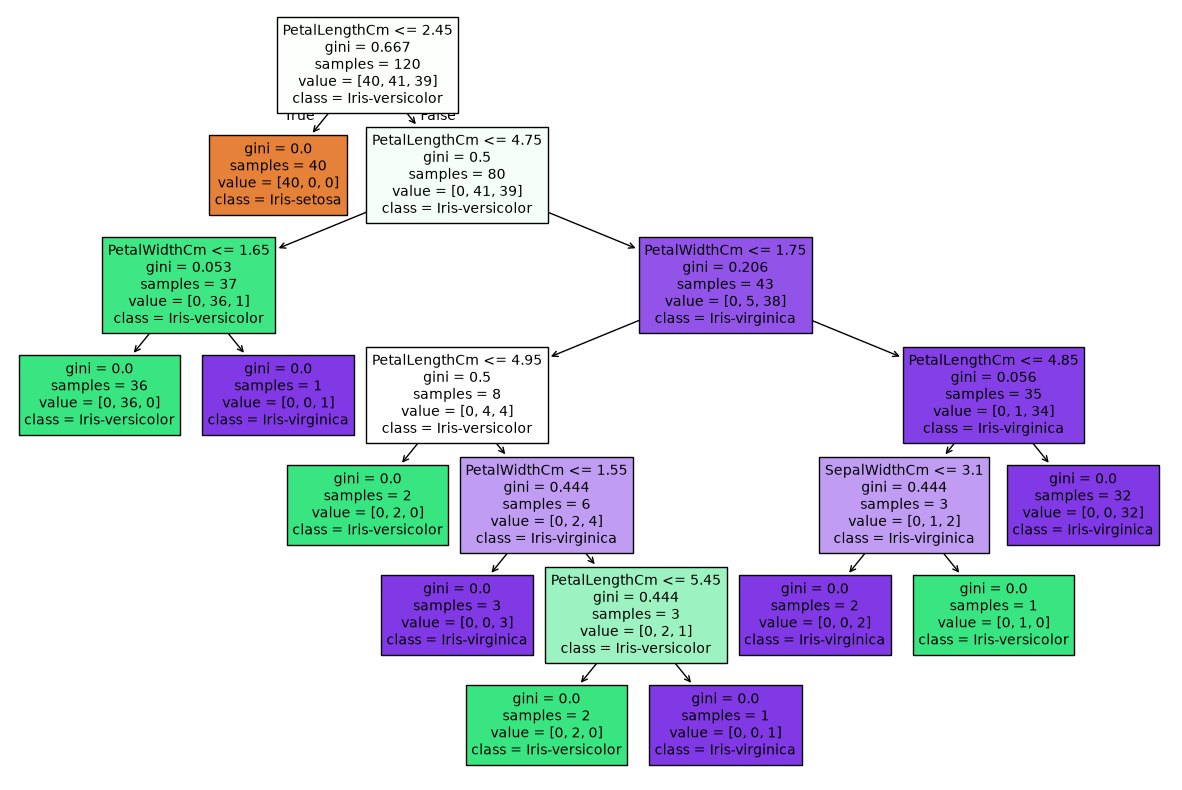

In [3]:
# Step 1: Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix

# Step 2: Load the dataset
df = pd.read_csv("decision tree/Iris (1).csv")
df.head()

# Step 3: Explore the data
df.shape
df.describe()
df.info()

# Step 4: Features (X) and target (Y)
# Id is just a row number, so it is left out
X = df[["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]]
Y = df["Species"]

# Step 5: Split into training and testing data
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42)

# Step 6: Train the model
# criterion="gini" measures node impurity (entropy is the alternative)
# Trees do not need feature scaling
model = DecisionTreeClassifier(criterion="gini", random_state=42)
model.fit(X_train, Y_train)

# Step 7: Predict
Y_pred = model.predict(X_test)

# Step 8: Evaluate
print("Accuracy:", accuracy_score(Y_test, Y_pred))

cm = confusion_matrix(Y_test, Y_pred)
print("confusion matrix:", cm)

# Step 9: Draw the tree so the decision rules can be read
plt.figure(figsize=(15, 10))
plot_tree(model,
          feature_names=X.columns,
          class_names=model.classes_,
          filled=True)
plt.show()


## Random Forest

Accuracy: 1.0
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        14
           3       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



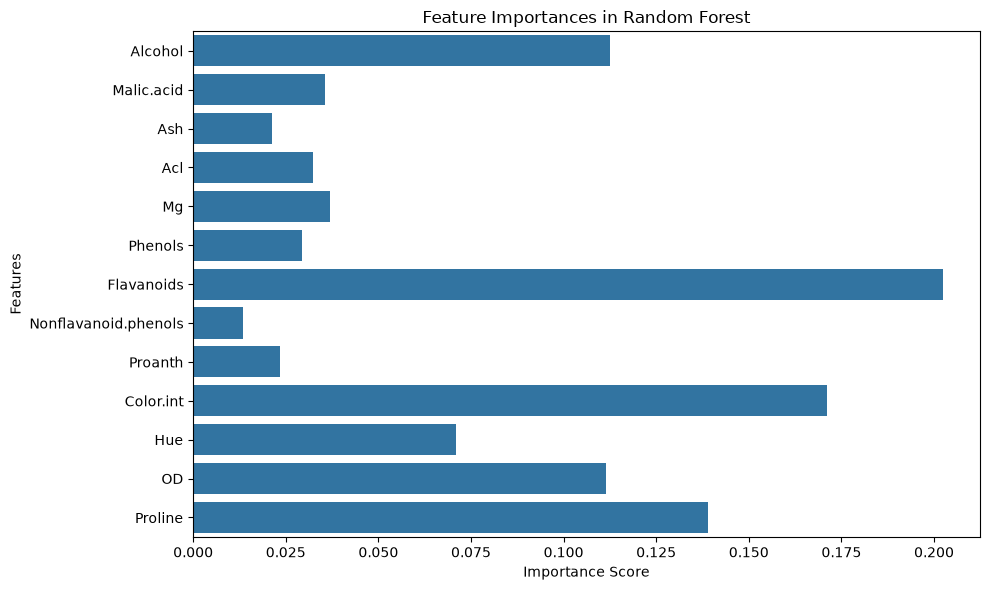

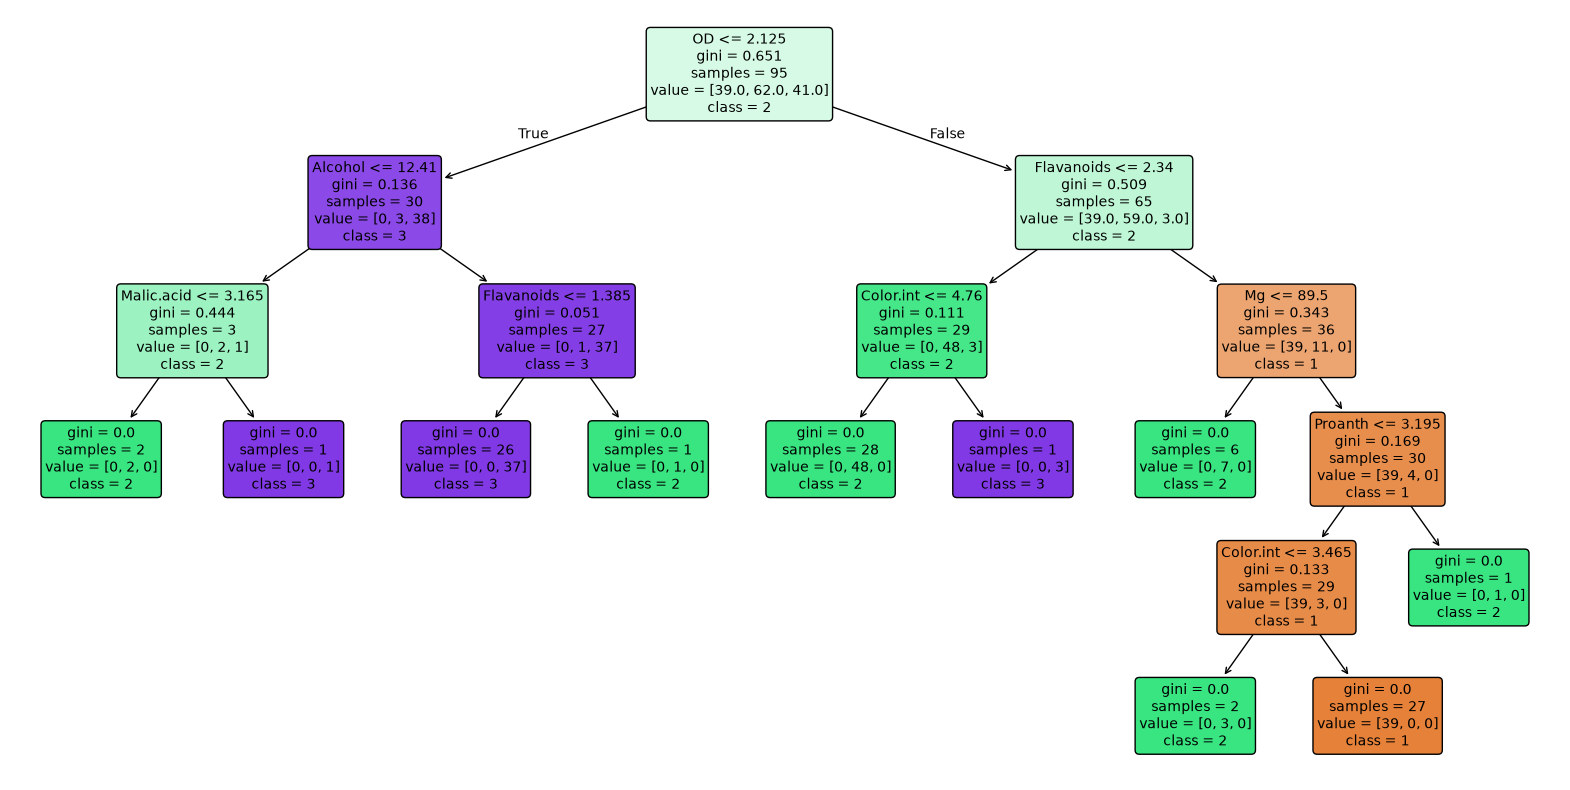

In [4]:
# Step 1: Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import plot_tree

# Step 2: Load the dataset
df = pd.read_csv("random forest/wine (1).csv")
df.head()
df.shape

# Step 3: Features (X) and target (y)
# "Wine" is the cultivar: class 1, 2 or 3
X = df.drop(columns=['Wine'])
y = df['Wine']

# Step 4: Split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Step 5: Train the forest
# n_estimators=100 means 100 trees vote on each prediction
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Step 6: Predict
y_pred = rf.predict(X_test)

# Step 7: Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Step 8: Feature importances - which chemicals decide the cultivar
plt.figure(figsize=(10, 6))
sns.barplot(x=rf.feature_importances_, y=X.columns)
plt.title("Feature Importances in Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

# Step 9: Visualise one single tree out of the 100
plt.figure(figsize=(20, 10))
plot_tree(rf.estimators_[0],
          filled=True,
          feature_names=X.columns,
          class_names=[str(cls) for cls in rf.classes_],
          rounded=True,
          fontsize=10)
plt.show()


## KNN

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        1000 non-null   str    
 1   Gender            1000 non-null   str    
 2   SeniorCitizen     1000 non-null   int64  
 3   Partner           1000 non-null   str    
 4   Dependents        1000 non-null   str    
 5   TenureMonths      1000 non-null   int64  
 6   InternetService   1000 non-null   str    
 7   Contract          1000 non-null   str    
 8   PaymentMethod     1000 non-null   str    
 9   TechSupport       1000 non-null   str    
 10  OnlineSecurity    1000 non-null   str    
 11  DeviceProtection  1000 non-null   str    
 12  PaperlessBilling  1000 non-null   str    
 13  MonthlyCharges    1000 non-null   float64
 14  TotalCharges      1000 non-null   float64
 15  Churn             1000 non-null   str    
dtypes: float64(2), int64(2), str(12)
memory usage: 185.2 K

C:\Users\Tatianv3\AppData\Local\Temp\ipykernel_21028\3657693871.py:23: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns


Accuracy: 0.63
[[95 31]
 [43 31]]
              precision    recall  f1-score   support

           0       0.69      0.75      0.72       126
           1       0.50      0.42      0.46        74

    accuracy                           0.63       200
   macro avg       0.59      0.59      0.59       200
weighted avg       0.62      0.63      0.62       200



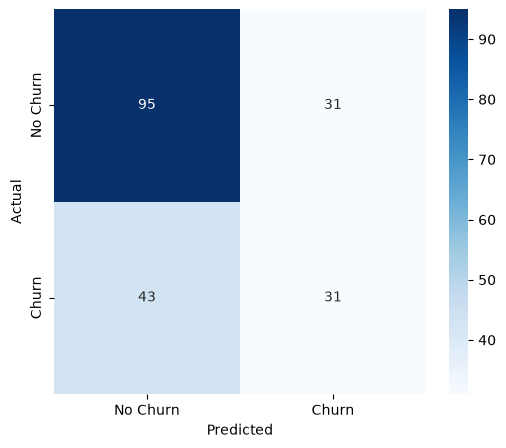

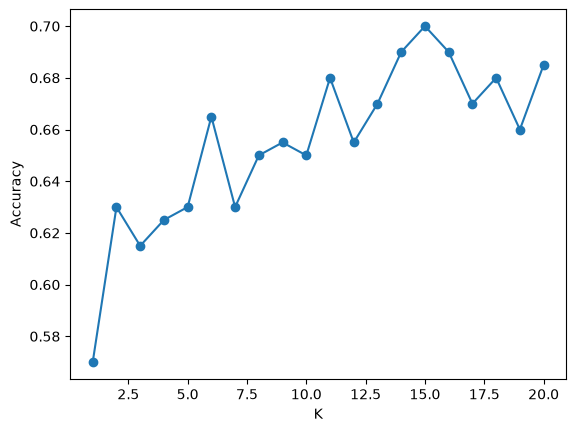

Best K: 15


In [5]:
# Step 1: Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Step 2: Load the dataset
df = pd.read_csv("knn/Customer_Churn_Dataset (1).csv")
df.head()
df.shape
df.info()

# Step 3: Drop the ID column - it carries no information
df = df.drop("CustomerID", axis=1)

# Step 4: Convert the target into numbers
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

# Step 5: Convert all remaining text columns into dummy variables
cat_cols = df.select_dtypes(include="object").columns
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Step 6: Features (X) and target (y)
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Step 7: Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Step 8: Feature scaling - COMPULSORY for KNN
# KNN measures distance, so TotalCharges (thousands) would otherwise
# completely outweigh columns like SeniorCitizen (0 or 1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 9: Train the model with K = 5 neighbours
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# Step 10: Predict
y_pred = knn.predict(X_test_scaled)

# Step 11: Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
print(cm)
print(classification_report(y_test, y_pred))

# Step 12: Confusion matrix heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Step 13: Try K from 1 to 20 and pick the best one
scores = []

for k in range(1, 21):
    m = KNeighborsClassifier(n_neighbors=k)
    m.fit(X_train_scaled, y_train)
    scores.append(accuracy_score(y_test, m.predict(X_test_scaled)))

plt.plot(range(1, 21), scores, marker="o")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.show()

print("Best K:", scores.index(max(scores)) + 1)


## Sentiment Analysis

Training data: 700
Testing data : 300
Number of TF-IDF features: 48
Accuracy : 0.5566666666666666
Precision: 0.5606060606060606
Recall   : 0.2624113475177305
F1 Score : 0.357487922705314


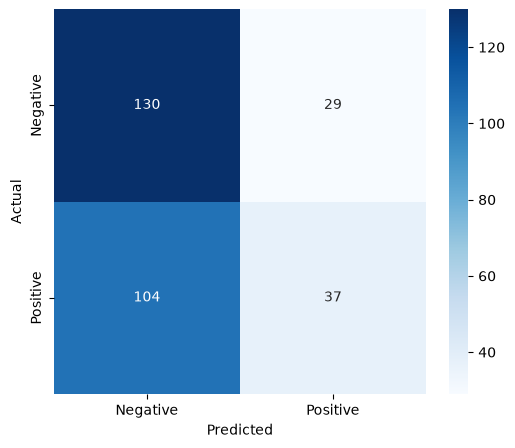

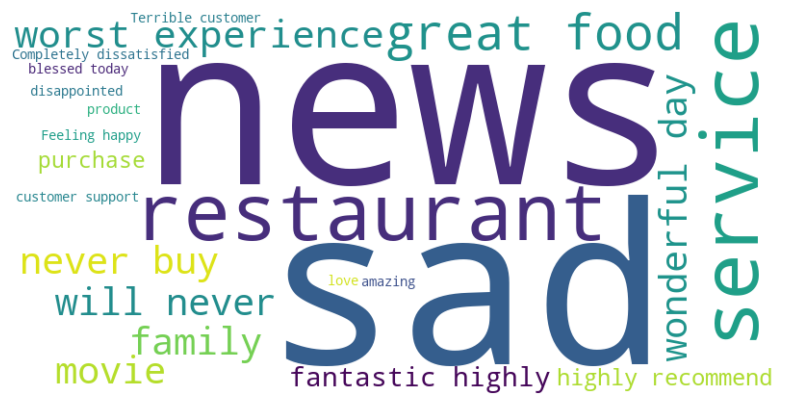

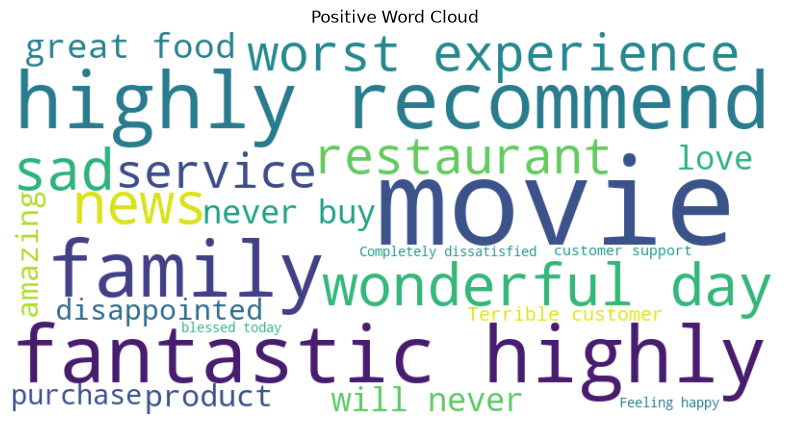

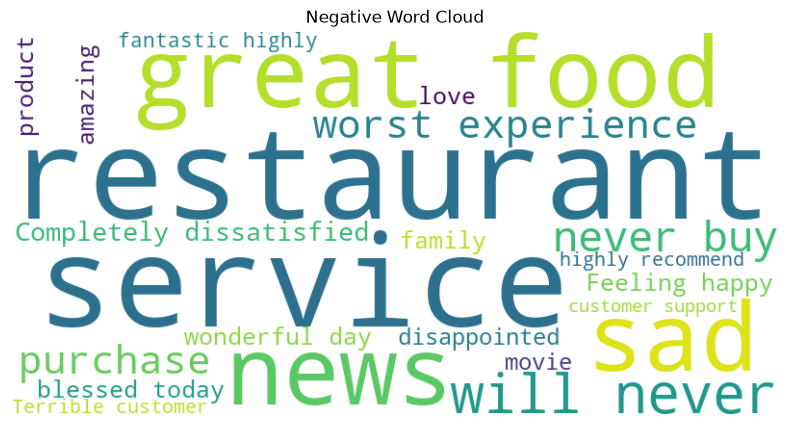

Predicted Sentiment: negative


In [6]:
# Step 1: Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix)

# Step 2: Load the dataset
df = pd.read_csv("sentiment analysis/tweets_dataset.csv")
df.head()
df.shape

# Step 3: Prepare the data
# fillna("") avoids errors on empty tweets, lower/strip cleans the labels
X = df["tweet"].fillna("")
y = df["sentiment"].str.lower().str.strip()

# Step 4: Train-test split (70% / 30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)

print("Training data:", len(X_train))
print("Testing data :", len(X_test))

# Step 5: TF-IDF - convert the text into numbers
# A word scores high if it is common in one tweet but rare overall
tfidf = TfidfVectorizer()
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Number of TF-IDF features:", X_train_tfidf.shape[1])

# Step 6: Train the model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

# Step 7: Predict
y_pred = model.predict(X_test_tfidf)

# Step 8: Evaluate
# pos_label="positive" is needed because the labels are text, not 0/1
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, pos_label="positive", zero_division=0))
print("Recall   :", recall_score(y_test, y_pred, pos_label="positive", zero_division=0))
print("F1 Score :", f1_score(y_test, y_pred, pos_label="positive", zero_division=0))

# Step 9: Confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Step 10: Word cloud of all tweets - bigger word = more frequent
all_text = " ".join(df["tweet"].astype(str))
wordcloud = WordCloud(width=800, height=400,
                      background_color="white").generate(all_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

# Step 11: Separate word clouds for positive and negative tweets
positive_text = " ".join(df[df["sentiment"] == "positive"]["tweet"].astype(str))
negative_text = " ".join(df[df["sentiment"] == "negative"]["tweet"].astype(str))

for text, title in [(positive_text, "Positive Word Cloud"),
                    (negative_text, "Negative Word Cloud")]:
    wc = WordCloud(width=800, height=400,
                   background_color="white").generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.show()

# Step 12: Predict the sentiment of a new review
# transform only - never fit_transform on new data
new_review = ["I really enjoyed this product. It is excellent!"]
print("Predicted Sentiment:", model.predict(tfidf.transform(new_review))[0])


## ARIMA

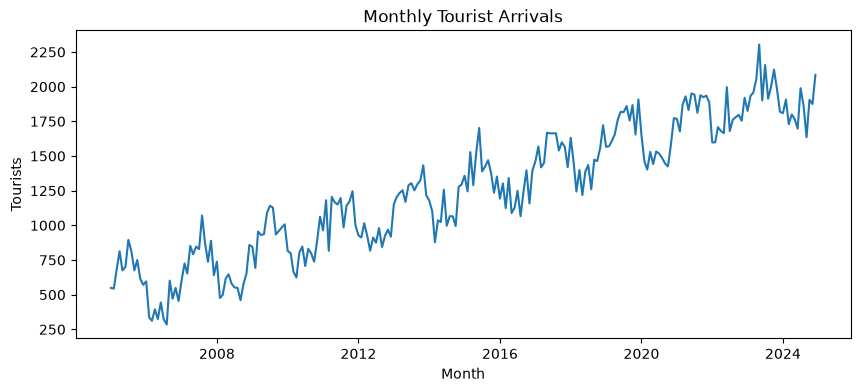

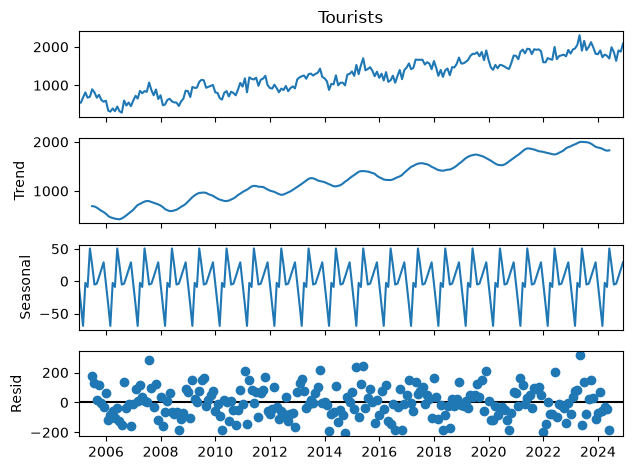

Training data: 216
Testing data : 24
                               SARIMAX Results                                
Dep. Variable:               Tourists   No. Observations:                  216
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -1348.521
Date:                Fri, 18 Sep 2026   AIC                           2703.041
Time:                        13:38:38   BIC                           2713.153
Sample:                    01-01-2005   HQIC                          2707.127
                         - 12-01-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2208      0.168     -1.315      0.189      -0.550       0.108
ma.L1         -0.2220      0.179     -1.239      0.215      -0.573       0.129
sigma2      1.6

C:\Users\Tatianv3\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Tatianv3\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Tatianv3\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


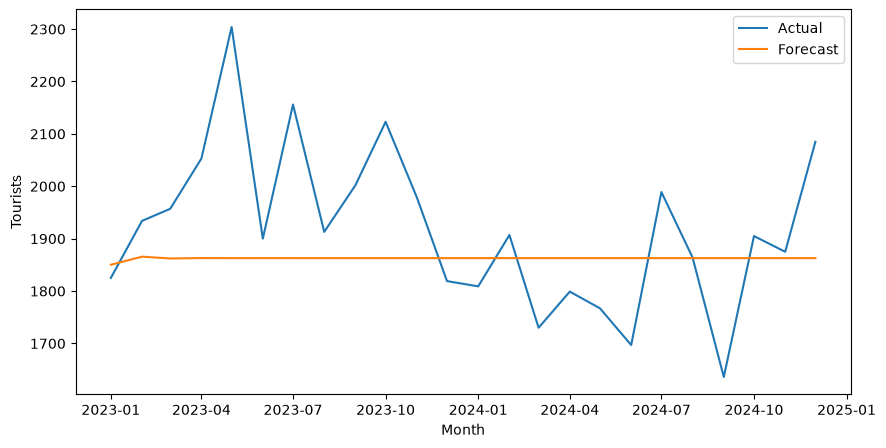

The forecast has good accuracy.
            Actual  Forecast
Month                       
2023-01-01  1825.0   1850.23
2023-02-01  1934.0   1865.64
2023-03-01  1957.0   1862.24
2023-04-01  2053.0   1862.99
2023-05-01  2304.0   1862.82
2023-06-01  1900.0   1862.86
2023-07-01  2156.0   1862.85
2023-08-01  1913.0   1862.85
2023-09-01  2002.0   1862.85
2023-10-01  2123.0   1862.85
2023-11-01  1979.0   1862.85
2023-12-01  1819.0   1862.85
2024-01-01  1809.0   1862.85
2024-02-01  1907.0   1862.85
2024-03-01  1730.0   1862.85
2024-04-01  1799.0   1862.85
2024-05-01  1767.0   1862.85
2024-06-01  1697.0   1862.85
2024-07-01  1989.0   1862.85
2024-08-01  1864.0   1862.85
2024-09-01  1636.0   1862.85
2024-10-01  1905.0   1862.85
2024-11-01  1875.0   1862.85
2024-12-01  2085.0   1862.85


In [7]:
# Step 1: Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_percentage_error

# Step 2: Load the dataset
df = pd.read_csv("time series/tourism_data_2005_onwards (1).csv")
df.head()
df.shape

# Step 3: Turn the Month column into a time-series index
# dayfirst=True because the dates are DD-MM-YYYY
df["Month"] = pd.to_datetime(df["Month"], dayfirst=True)
df = df.sort_values("Month")
df["Month"] = df["Month"].dt.to_period("M").dt.to_timestamp()
df = df.set_index("Month")

tourists = df["Tourists"].astype(float)

# Step 4: Plot the series - look for trend and seasonality
plt.figure(figsize=(10, 4))
plt.plot(tourists)
plt.title("Monthly Tourist Arrivals")
plt.xlabel("Month")
plt.ylabel("Tourists")
plt.show()

# Step 5: Decomposition into trend + seasonal + residual
# period=12 because the data is monthly
result = seasonal_decompose(tourists, model="additive", period=12)
result.plot()
plt.show()

# Step 6: Split the data CHRONOLOGICALLY - never shuffle a time series
# The last 24 months are the test set
train = tourists[:-24]
test = tourists[-24:]

print("Training data:", len(train))
print("Testing data :", len(test))

# Step 7: Build the ARIMA model
# order = (p, d, q):  p = AR lags, d = differencing, q = MA terms
model = ARIMA(train, order=(1, 1, 1))
model_fit = model.fit()
print(model_fit.summary())

# Step 8: Forecast the same number of months as the test set
forecast = model_fit.forecast(steps=len(test))
forecast.index = test.index      # match the dates so they plot together
print(forecast)

# Step 9: MAPE - the average error as a percentage
mape = mean_absolute_percentage_error(test, forecast) * 100
print("MAPE:", round(mape, 2), "%")

# Step 10: Plot actual vs forecast
plt.figure(figsize=(10, 5))
plt.plot(test.index, test, label="Actual")
plt.plot(forecast.index, forecast, label="Forecast")
plt.xlabel("Month")
plt.ylabel("Tourists")
plt.legend()
plt.show()

# Step 11: Interpretation - under 10% MAPE is a good forecast
if mape < 10:
    print("The forecast has good accuracy.")
else:
    print("The forecast has higher error.")

# Step 12: Actual and forecast side by side
result_df = pd.DataFrame({"Actual": test, "Forecast": forecast})
print(result_df.round(2))
